# Taxi fare prediction model

## 1. Loading Data  and Data Type

In [73]:
import pandas as pd
import numpy as np

# Load the datasets
train_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv')

In [74]:
# Inspection
print("Train Info:")
print(train_df.info())

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  floa

In [75]:
print("\nTest Info:")
print(test_df.info())


Test Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1500 non-null   int64  
 1   VendorID               1500 non-null   int64  
 2   tpep_pickup_datetime   1500 non-null   object 
 3   tpep_dropoff_datetime  1500 non-null   object 
 4   passenger_count        1445 non-null   float64
 5   trip_distance          1500 non-null   float64
 6   RatecodeID             1445 non-null   float64
 7   store_and_fwd_flag     1445 non-null   object 
 8   PULocationID           1500 non-null   int64  
 9   DOLocationID           1500 non-null   int64  
 10  payment_type           1500 non-null   object 
 11  extra                  1500 non-null   float64
 12  tip_amount             1500 non-null   float64
 13  tolls_amount           1500 non-null   float64
 14  improvement_surcharge  1500 non-null   float

In [76]:
# Identify data types
data_types = train_df.dtypes
print("\nData Types:\n", data_types)


Data Types:
 VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type              object
extra                    float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
Airport_fee              float64
dtype: object


## 2. Descriptive statistics of numerical columns

In [78]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
desc_stats = train_df[numerical_cols].describe().T
print("Descriptive Statistics:\n", desc_stats)

Descriptive Statistics:
                          count        mean        std         min        25%  \
VendorID               10000.0    0.729100   0.444672    0.000000   0.000000   
passenger_count         9634.0    1.357276   0.883676    0.000000   1.000000   
trip_distance          10000.0    3.679527   4.905798    0.000000   1.070000   
RatecodeID              9634.0    1.450695   5.988978    1.000000   1.000000   
PULocationID           10000.0  132.710800  75.789597    1.000000  67.000000   
DOLocationID           10000.0  132.332400  75.959440    1.000000  68.000000   
extra                  10000.0    1.940950   1.945885   -7.500000   0.000000   
tip_amount             10000.0    6.094658   4.438894    0.000713   3.466789   
tolls_amount           10000.0    0.664425   2.441070  -26.550000   0.000000   
improvement_surcharge  10000.0    0.979490   0.200076   -1.000000   1.000000   
total_amount           10000.0   29.740157  26.256398 -129.300000  16.300000   
congestion_surc

## 3.Identify and handle missing values

In [79]:
missing_values = train_df.isnull().sum()
print("\nMissing Values in Train:\n", missing_values)


Missing Values in Train:
 VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64


In [81]:
# Strategy: Impute numerical with median, categorical with mode
for col in train_df.columns:
    if train_df[col].isnull().any():
        if train_df[col].dtype == 'object':
            train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
        else:
            train_df[col] = train_df[col].fillna(train_df[col].median())

In [82]:
# Apply same to test
for col in test_df.columns:
    if test_df[col].isnull().any():
        if test_df[col].dtype == 'object':
            test_df[col] = test_df[col].fillna(test_df[col].mode()[0])
        else:
            test_df[col] = test_df[col].fillna(test_df[col].median())

## 4. Identify and handle duplicates

In [83]:
duplicates = train_df.duplicated().sum()
print(f"\nNumber of duplicates: {duplicates}")
if duplicates > 0:
    train_df = train_df.drop_duplicates()


Number of duplicates: 0


## 5. Identify and handle outliers 

Text(0.5, 1.0, 'Boxplot of Numerical Features')

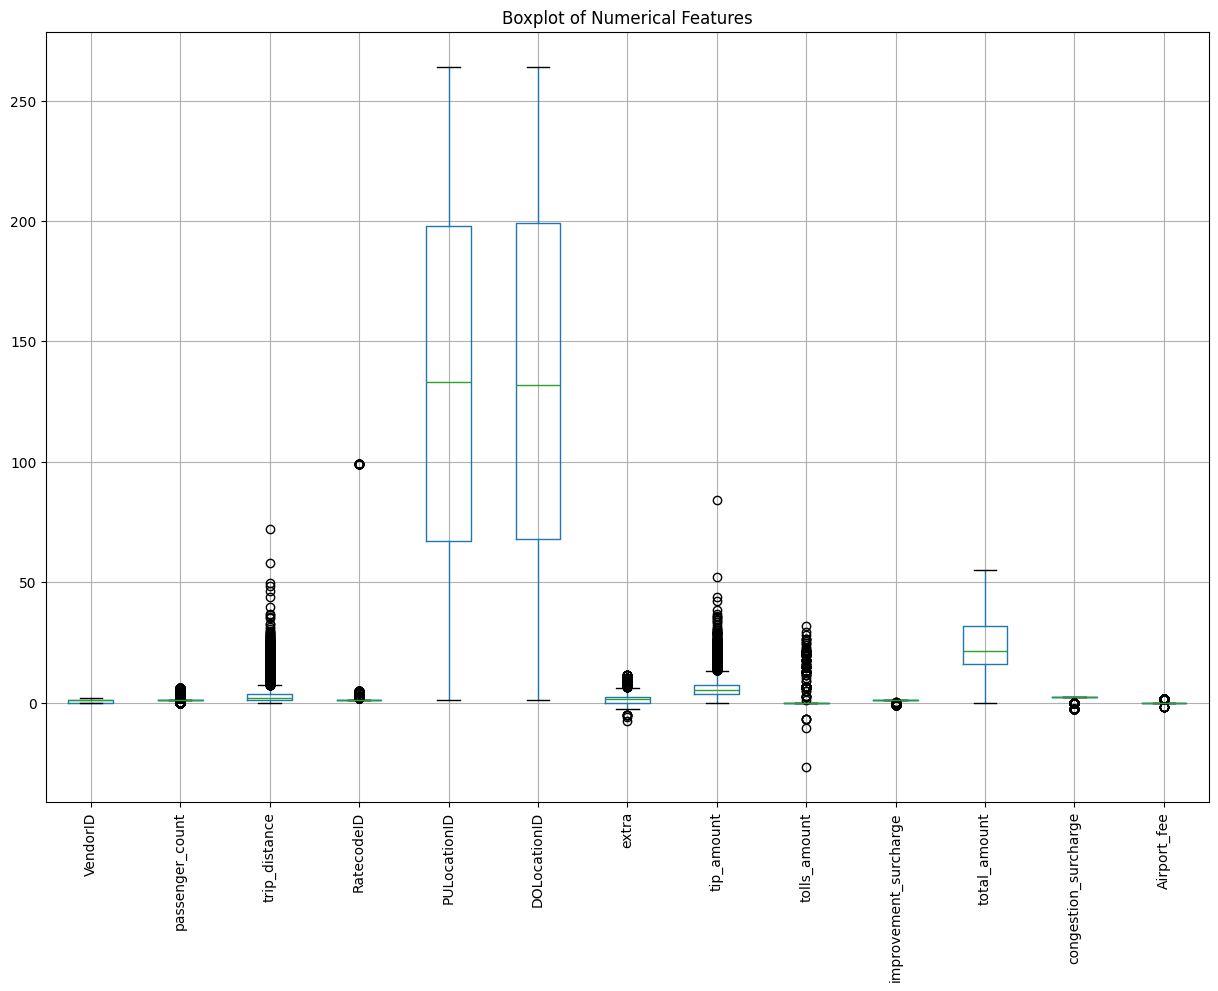

In [144]:
plt.figure(figsize=(15, 10))
train_df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")

In [84]:
# Using IQR method for total_amount as an example
Q1 = train_df['total_amount'].quantile(0.25)
Q3 = train_df['total_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [85]:
# Capping outliers instead of dropping to keep data size
train_df['total_amount'] = np.clip(train_df['total_amount'], lower_bound, upper_bound)
# Also check for negative distances or amounts
train_df['trip_distance'] = train_df['trip_distance'].apply(lambda x: max(x, 0))
train_df['total_amount'] = train_df['total_amount'].apply(lambda x: max(x, 0))

In [86]:
print("\nMissing values after handling:", train_df.isnull().sum().sum())


Missing values after handling: 0


### features extraction

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
# Convert datetime columns
train_df['tpep_pickup_datetime'] = pd.to_datetime(train_df['tpep_pickup_datetime'])
train_df['tpep_dropoff_datetime'] = pd.to_datetime(train_df['tpep_dropoff_datetime'])
test_df['tpep_pickup_datetime'] = pd.to_datetime(test_df['tpep_pickup_datetime'])
test_df['tpep_dropoff_datetime'] = pd.to_datetime(test_df['tpep_dropoff_datetime'])

In [89]:
def extract_features(df):
    df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    # Handle negative durations (data noise)
    df['trip_duration'] = df['trip_duration'].apply(lambda x: max(x, 0))
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    return df

In [90]:
train_df = extract_features(train_df)
test_df = extract_features(test_df)

## 6.Visualizations

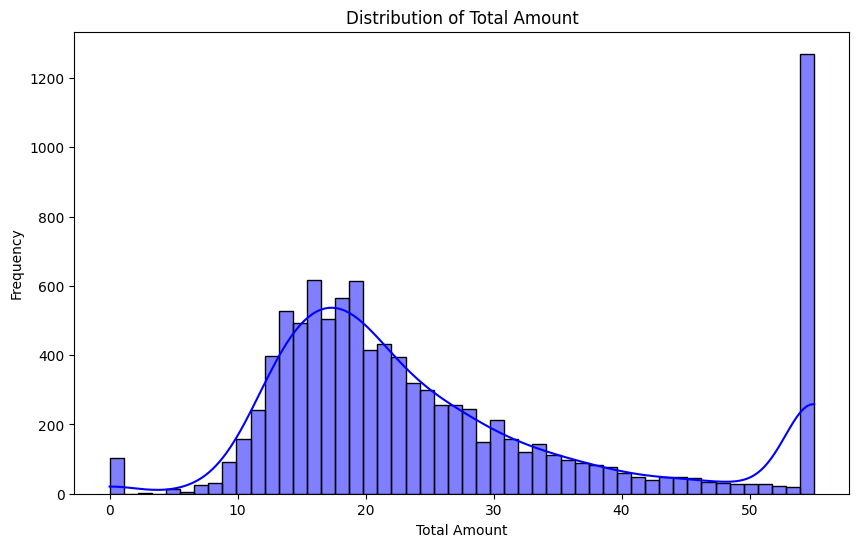

In [91]:
# Plot 1: Distribution of Total Amount
plt.figure(figsize=(10, 6))
sns.histplot(train_df['total_amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.savefig('total_amount_dist.png')

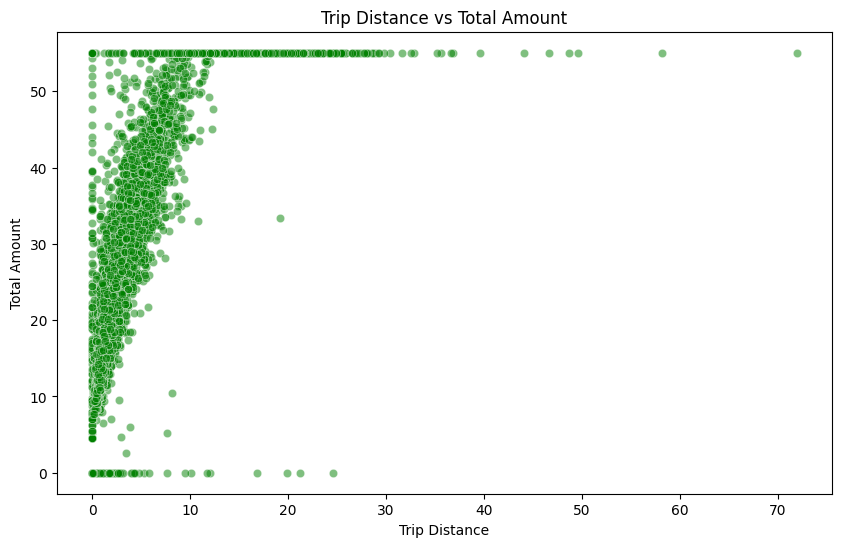

In [92]:
# Plot 2: Trip Distance vs Total Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='total_amount', data=train_df, alpha=0.5, color='green')
plt.title('Trip Distance vs Total Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Total Amount')
plt.savefig('distance_vs_amount.png')

/tmp/ipykernel_55/1391664355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')


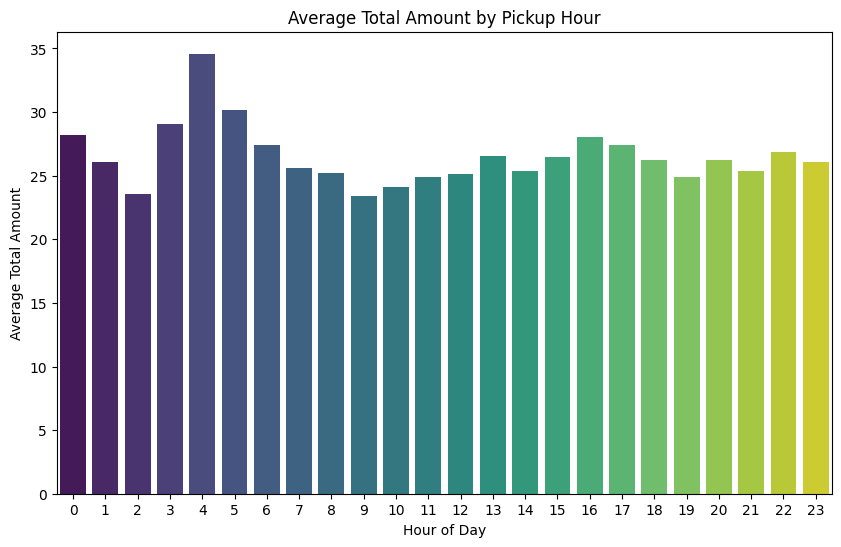

In [93]:
# Plot 3: Average Total Amount by Pickup Hour
plt.figure(figsize=(10, 6))
hourly_avg = train_df.groupby('pickup_hour')['total_amount'].mean()
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')
plt.title('Average Total Amount by Pickup Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Total Amount')
plt.savefig('hourly_avg_amount.png')

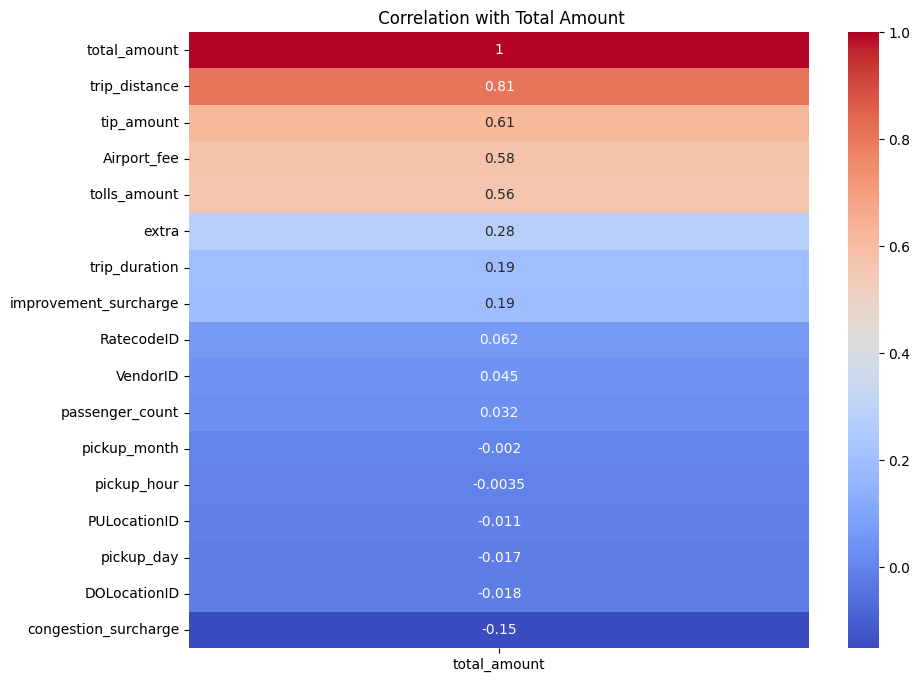

<Figure size 640x480 with 0 Axes>

In [95]:
# Plot 4: Co-relation matrix
plt.figure(figsize=(10, 8))
num_corr = train_df.select_dtypes(include=['float64', 'int64', 'int32']).corr()
sns.heatmap(num_corr[['total_amount']].sort_values(by='total_amount', ascending=False), annot=True, cmap='coolwarm')
plt.title(' Correlation with Total Amount')
plt.show()
plt.savefig('Correaltion_with_total_amount.png')

## 7. Scale Numerical features and Encode Categorical features

In [103]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV

In [97]:
# Define features and target
X = train_df.drop(columns=['total_amount', 'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
y = train_df['total_amount']

In [98]:
# Identify numeric and categorical columns
numeric_features = ['passenger_count', 'trip_distance', 'extra', 'tip_amount', 'tolls_amount', 
                    'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 
                    'trip_duration', 'pickup_hour', 'pickup_day', 'pickup_month']
categorical_features = ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'PULocationID', 'DOLocationID']

In [116]:
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

In [118]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', ohe, categorical_features)
    ])

In [119]:
# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Implementing Baseline Models

In [120]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score

In [125]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest(baseline)': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees(baseline)': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Hist Gradient Boosting(baseline)': HistGradientBoostingRegressor(random_state=42)
}

In [127]:
results = {}
trained_pipelines = {}

In [128]:
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    results[name] = r2_score(y_val, y_pred)
    trained_pipelines[name] = pipeline

In [129]:
print("Model Comparison(baseline ) (R2 Score):")
for name, score in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {score:.4f}")

Model Comparison(baseline ) (R2 Score):
Extra Trees(baseline): 0.9347
Hist Gradient Boosting(baseline): 0.9346
Random Forest(baseline): 0.9339
Gradient Boosting: 0.9312
Decision Tree: 0.9029
Ridge: 0.7083
Linear Regression: 0.7057
Lasso: 0.7050


## 9. Improved model(hypertuning top 3 baseline model)

In [131]:
# Tuning HGB 
hgb_param = {'regressor__max_iter': [100, 200], 'regressor__learning_rate': [0.1]}
gs_hgb = GridSearchCV(trained_pipelines['Hist Gradient Boosting(baseline)'], hgb_param, cv=2).fit(X_train, y_train)
results['Hist Gradient Boosting(tuned)'] = r2_score(y_val, gs_hgb.predict(X_val))


In [132]:
# Tuning ET
et_param = {'regressor__n_estimators': [100]}
gs_et = GridSearchCV(trained_pipelines['Extra Trees(baseline)'], et_param, cv=2).fit(X_train, y_train)
results['Extra Trees(tuned)'] = r2_score(y_val, gs_et.predict(X_val))

In [134]:
# Tuning Random forest
rf_param={}
gs_rf=GridSearchCV(trained_pipelines['Random Forest(baseline)'],rf_param,cv=2).fit(X_train,y_train)
results['Random Forest(tuned)'] = r2_score(y_val, gs_et.predict(X_val))

In [135]:
print("Model Comparison(Tuned and Baseline ) (R2 Score):")
for name, score in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {score:.4f}")

Model Comparison(Tuned and Baseline ) (R2 Score):
Extra Trees(baseline): 0.9347
Extra Trees(tuned): 0.9347
Random Forest(tuned): 0.9347
Hist Gradient Boosting(baseline): 0.9346
Random Forest(baseline): 0.9339
Hist Gradient Boosting(tuned): 0.9337
Gradient Boosting: 0.9312
Decision Tree: 0.9029
Ridge: 0.7083
Linear Regression: 0.7057
Lasso: 0.7050


## 10. Final Prediction with  BEST Model


In [141]:
best_model = gs_rf
test_X = test_df.drop(columns=['id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime'])
preds = best_model.predict(test_X)

submission = pd.DataFrame({'id': test_df['id'], 'total_amount': preds})
submission.to_csv('submission.csv', index=False)
print("\nSubmission saved to submission.csv")


Submission saved to submission.csv


In [142]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1500 non-null   int64  
 1   total_amount  1500 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 23.6 KB
